In [1]:
import urllib.error
import urllib.request
import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model

import langchain_groq
import os

from dotenv import load_dotenv

load_dotenv()

True

In [2]:

model_groq_lamma70b = init_chat_model("llama-3.3-70b-versatile",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

# model = init_chat_model("openai/gpt-4o-mini",
#                         api_key=os.environ["OPENROUTER_API_KEY"],
#                         model_provider="openrouter",
#                         base_url="https://openrouter.ai/api/v1",
#                         max_tokens=1000, temperature=0.0)

# model = init_chat_model("nvidia/nemotron-3-ultra-550b-a55b:free",
#                         api_key=os.environ["OPENROUTER_API_KEY"],
#                         model_provider="openrouter",
#                         base_url="https://openrouter.ai/api/v1",
#                         max_tokens=1000, temperature=0.0)


# model = init_chat_model("openrouter/free",
#                         api_key=os.environ["OPENROUTER_API_KEY"],
#                         model_provider="openrouter",
#                         base_url="https://openrouter.ai/api/v1",
#                         max_tokens=1000, temperature=0.0)


model_or = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_or_paid_gpt56_luna_pro = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)


In [10]:
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain.agents.middleware import (
    ShellToolMiddleware,
    HostExecutionPolicy,
    DockerExecutionPolicy,
    RedactionRule,
)

agent = create_agent(
    model=model_or_paid_gpt56_luna_pro,
    tools=[],
    middleware=[ ShellToolMiddleware(
            workspace_root="./workspace/cinebot_workspace",
            execution_policy=HostExecutionPolicy(),
        ),]
    )

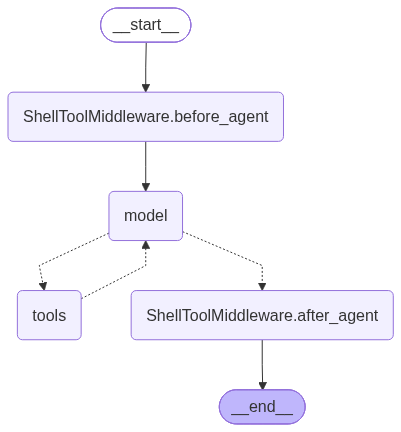

In [11]:
agent

In [12]:
from rich import print as rprint

In [21]:
from pathlib import Path

workspace_root = (Path.cwd() / "workspace" / "cinebot_workspace").resolve()
workspace_root.mkdir(parents=True, exist_ok=True)

# # optional: create the reports folder now so the agent doesn't need to
# reports_dir = workspace_root / "reports"
# reports_dir.mkdir(exist_ok=True)

agent = create_agent(
    model=model_or_paid_gpt56_luna_pro,
    tools=[],
    middleware=[
        ShellToolMiddleware(
            workspace_root=str(workspace_root),
            shell_command=[r"C:\WINDOWS\system32\bash.EXE"],
            execution_policy=HostExecutionPolicy(),
        )
    ],
)


In [22]:
result = agent.invoke({"messages": [("user", "Create a reports folder if the same doesn't exist.")]})

Command timed out after 30.00 seconds; restarting shell session.


RuntimeError: Shell session is not running.

In [20]:
import langchain
import shutil

print("LangChain:", langchain.__version__)

for executable in ["cmd", "powershell", "pwsh", "bash", "sh"]:
    print(executable, "=>", shutil.which(executable))

LangChain: 1.3.14
cmd => C:\WINDOWS\system32\cmd.EXE
powershell => C:\WINDOWS\System32\WindowsPowerShell\v1.0\powershell.EXE
pwsh => None
bash => C:\WINDOWS\system32\bash.EXE
sh => None
